In [1]:
!pip install -q transformers datasets accelerate evaluate seqeval scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [2]:
import os, re, gc, unicodedata, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from transformers import (
    AutoTokenizer,
    XLMRobertaModel,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    get_linear_schedule_with_warmup
)

import evaluate
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "xlm-roberta-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
DATA_DIR = "/kaggle/input/datasets/linhnguyen1304/real-dataset"

files = {
    "fashion_vi": "tiki_reviews_men_fashion_5000.csv",
    "skincare_vi": "tiki_reviews_skincare.csv",
    "book_en": "book.csv",
    "book_mixed": "book_vi_merged_dataset.csv",
    "fashion_en": "Fashion-en.csv",
    "skincare_en": "sephora_reviews_skincare.csv",
}

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def rating_to_sentiment(rating):
    try:
        rating = float(rating)
    except Exception:
        return None
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    return "positive"

def pick_col(df, candidates):
    lower_map = {c.lower().strip(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower().strip() in lower_map:
            return lower_map[c.lower().strip()]
    return None

def standardize_tiki(path, domain, language, source):
    df = pd.read_csv(path)
    review_col = pick_col(df, ["review", "comment", "content", "text", "Review Text"])
    rating_col = pick_col(df, ["rating", "Rating", "stars", "score"])
    out = pd.DataFrame()
    out["review"] = df[review_col] if review_col else ""
    out["rating"] = df[rating_col] if rating_col else np.nan
    out["domain"] = domain
    out["language"] = language
    out["source"] = source
    return out

def standardize_book_en(path):
    df = pd.read_csv(path)
    review_col = pick_col(df, ["reviewText", "review", "Review Text", "text"])
    summary_col = pick_col(df, ["summary", "Summary", "title"])
    rating_col = pick_col(df, ["rating", "Rating", "overall", "score"])
    review = df[review_col].fillna("") if review_col else ""
    if summary_col:
        review = review.astype(str) + " " + df[summary_col].fillna("").astype(str)
    out = pd.DataFrame({
        "review": review,
        "rating": df[rating_col] if rating_col else np.nan,
        "domain": "book",
        "language": "en",
        "source": "amazon"
    })
    return out

def standardize_book_mixed(path):
    df = pd.read_csv(path)
    required = ["review", "rating", "domain", "language", "source"]
    if all(c in df.columns for c in required):
        return df[required].copy()
    review_col = pick_col(df, ["review", "comment", "reviewText", "text"])
    rating_col = pick_col(df, ["rating", "Rating", "overall", "score"])
    out = pd.DataFrame()
    out["review"] = df[review_col] if review_col else ""
    out["rating"] = df[rating_col] if rating_col else np.nan
    out["domain"] = "book"
    out["language"] = df["language"] if "language" in df.columns else "vi"
    out["source"] = df["source"] if "source" in df.columns else "mixed"
    return out

def standardize_fashion_en(path):
    df = pd.read_csv(path)
    review_col = pick_col(df, ["Review Text", "review", "text"])
    rating_col = pick_col(df, ["Rating", "rating", "score"])
    out = pd.DataFrame()
    out["review"] = df[review_col] if review_col else ""
    out["rating"] = df[rating_col] if rating_col else np.nan
    out["domain"] = "fashion"
    out["language"] = "en"
    out["source"] = "fashion_dataset"
    return out

paths = {k: os.path.join(DATA_DIR, v) for k, v in files.items()}

datasets = [
    standardize_tiki(paths["fashion_vi"], "fashion", "vi", "tiki"),
    standardize_tiki(paths["skincare_vi"], "skincare", "vi", "tiki"),
    standardize_book_en(paths["book_en"]),
    standardize_book_mixed(paths["book_mixed"]),
    standardize_fashion_en(paths["fashion_en"]),
    standardize_tiki(paths["skincare_en"], "skincare", "en", "sephora"),
]

df = pd.concat(datasets, ignore_index=True)
df["review"] = df["review"].apply(clean_text)
df["sentiment"] = df["rating"].apply(rating_to_sentiment)

df = df.dropna(subset=["review", "rating", "sentiment", "domain", "language"])
df = df[df["review"].str.len() >= 10]
df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

print("Raw clean shape:", df.shape)
display(df.head())

Raw clean shape: (79098, 6)


,review,rating,domain,language,source,sentiment
0,"Gửi đủ, mà màu có tối có sáng, mua cho pâp mà ...",4,fashion,vi,tiki,positive
1,"Quá thơm bơ, quá đẳng cấp, ko ngờ mua dc giá h...",5,fashion,vi,tiki,positive
2,"Quần may kỹ lưỡng, vải mát, mặc thoải mái. với...",5,fashion,vi,tiki,positive
3,Mình mua 2 set: 10 quần. Không ngờ Giá cả rẻ h...,5,fashion,vi,tiki,positive
4,Mình đặt hàng từ 17/9 và mãi tới 10/11 mới nhậ...,3,fashion,vi,tiki,neutral


In [4]:
print("Language")
display(df["language"].value_counts())
print("Domain")
display(df["domain"].value_counts())
print("Sentiment")
display(df["sentiment"].value_counts())
print("Domain x Language")
display(pd.crosstab(df["domain"], df["language"]))
print("Domain x Sentiment")
display(pd.crosstab(df["domain"], df["sentiment"]))

Language


language
en    44025
vi    35073
Name: count, dtype: int64

Domain


domain
fashion     26967
skincare    26423
book        25708
Name: count, dtype: int64

Sentiment


sentiment
positive    55963
negative    14243
neutral      8892
Name: count, dtype: int64

Domain x Language


language,en,vi
domain,,
book,12000,13708
fashion,22633,4334
skincare,9392,17031


Domain x Sentiment


sentiment,negative,neutral,positive
domain,,,
book,8156,4096,13456
fashion,2942,3202,20823
skincare,3145,1594,21684


In [5]:
def is_bad_review(text):
    text = str(text).strip().lower()
    if text == "": return True
    if len(text.split()) < 3: return True
    if text in ["ok", "oke", "good", "nice", "đẹp", "hay", "tốt", "ổn", "great", "bad"]:
        return True
    return False

df_clean = df.copy()
df_clean = df_clean[~df_clean["review"].apply(is_bad_review)]
df_clean = df_clean.drop_duplicates(subset=["review"]).reset_index(drop=True)

TARGET_PER_SENTIMENT = 12000
parts = []
for sentiment, group in df_clean.groupby("sentiment"):
    parts.append(group.sample(n=TARGET_PER_SENTIMENT, replace=len(group)<TARGET_PER_SENTIMENT, random_state=SEED))

balanced_df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

# optional: balance sâu hơn theo domain-language-sentiment
TARGET_PER_GROUP = 2000
parts = []
for keys, group in df_clean.groupby(["domain", "language", "sentiment"]):
    parts.append(group.sample(n=TARGET_PER_GROUP, replace=len(group)<TARGET_PER_GROUP, random_state=SEED))
final_df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("balanced_df:", balanced_df.shape)
print("final_df:", final_df.shape)
display(final_df["sentiment"].value_counts())
display(pd.crosstab(final_df["domain"], final_df["language"]))
display(pd.crosstab(final_df["domain"], final_df["sentiment"]))

balanced_df: (36000, 6)
final_df: (36000, 6)


sentiment
positive    12000
negative    12000
neutral     12000
Name: count, dtype: int64

language,en,vi
domain,,
book,6000,6000
fashion,6000,6000
skincare,6000,6000


sentiment,negative,neutral,positive
domain,,,
book,4000,4000,4000
fashion,4000,4000,4000
skincare,4000,4000,4000


In [6]:
aspect_dicts = {
    "fashion": {
        "size": ["size", "chật", "rộng", "vừa", "fit", "tight", "loose", "small", "large"],
        "quality": ["vải", "chất liệu", "fabric", "material", "cotton"],
        "design": ["đẹp", "xấu", "style", "mẫu", "design", "beautiful", "ugly"],
        "shipping": ["ship", "giao hàng", "delivery"]
    },
    "skincare": {
        "effect": ["ẩm", "mịn", "dưỡng", "moisturizing", "smooth"],
        "irritation": ["mụn", "kích ứng", "irritation", "breakout"],
        "smell": ["mùi", "hương", "smell", "fragrance"],
        "packaging": ["bao bì", "đóng gói", "packaging"]
    },
    "book": {
        "content": ["nội dung", "content", "cốt truyện", "story"],
        "translation": ["dịch", "bản dịch", "translate", "translation"],
        "paper": ["giấy", "paper"],
        "delivery": ["ship", "giao hàng", "delivery"]
    }
}

def extract_aspects(review, domain):
    review_lower = str(review).lower()
    found = []
    for aspect, keywords in aspect_dicts.get(domain, {}).items():
        if any(kw.lower() in review_lower for kw in keywords):
            found.append(aspect)
    return sorted(list(set(found)))

final_df["aspects"] = final_df.apply(lambda r: extract_aspects(r["review"], r["domain"]), axis=1)
aspect_df = final_df[final_df["aspects"].apply(len) > 0].reset_index(drop=True)

from collections import Counter
aspect_counter = Counter([a for xs in aspect_df["aspects"] for a in xs])
print("aspect_df:", aspect_df.shape)
print(aspect_counter)

aspect_df: (17844, 7)
Counter({'size': 5044, 'content': 4442, 'quality': 3340, 'design': 2653, 'effect': 2487, 'smell': 1566, 'irritation': 819, 'packaging': 812, 'delivery': 697, 'shipping': 596, 'paper': 228, 'translation': 151})


In [7]:
rows = []
for _, row in aspect_df.iterrows():
    for asp in row["aspects"]:
        rows.append({
            "review": row["review"],
            "domain": row["domain"],
            "language": row["language"],
            "source": row["source"],
            "rating": row["rating"],
            "sentiment": row["sentiment"],
            "aspect": asp
        })

aspect_long_df = pd.DataFrame(rows)
TARGET_PER_ASPECT = 1500
parts = []
for asp, group in aspect_long_df.groupby("aspect"):
    parts.append(group.sample(n=TARGET_PER_ASPECT, replace=len(group)<TARGET_PER_ASPECT, random_state=SEED))

aspect_train_df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("aspect_train_df:", aspect_train_df.shape)
display(aspect_train_df["aspect"].value_counts())
display(pd.crosstab(aspect_train_df["aspect"], aspect_train_df["sentiment"]))

final_df.to_csv("phase2_clean_balanced_dataset.csv", index=False, encoding="utf-8-sig")
aspect_train_df.to_csv("phase3_aspect_train_balanced.csv", index=False, encoding="utf-8-sig")

aspect_train_df: (18000, 7)


aspect
delivery       1500
irritation     1500
paper          1500
effect         1500
content        1500
quality        1500
translation    1500
smell          1500
packaging      1500
size           1500
design         1500
shipping       1500
Name: count, dtype: int64

sentiment,negative,neutral,positive
aspect,,,
content,488,548,464
delivery,386,437,677
design,421,463,616
effect,356,441,703
irritation,589,457,454
packaging,459,458,583
paper,402,420,678
quality,556,498,446
shipping,348,311,841


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

mt_df = aspect_train_df.dropna(subset=["review", "aspect", "sentiment", "domain", "language"]).reset_index(drop=True)

mt_aspect_encoder = LabelEncoder()
mt_sentiment_encoder = LabelEncoder()
mt_domain_encoder = LabelEncoder()
mt_language_encoder = LabelEncoder()

mt_df["aspect_label"] = mt_aspect_encoder.fit_transform(mt_df["aspect"])
mt_df["sentiment_label"] = mt_sentiment_encoder.fit_transform(mt_df["sentiment"])
mt_df["domain_label"] = mt_domain_encoder.fit_transform(mt_df["domain"])
mt_df["language_label"] = mt_language_encoder.fit_transform(mt_df["language"])

print("Aspect:", mt_aspect_encoder.classes_)
print("Sentiment:", mt_sentiment_encoder.classes_)
print("Domain:", mt_domain_encoder.classes_)
print("Language:", mt_language_encoder.classes_)

train_df, val_df = train_test_split(mt_df, test_size=0.2, random_state=SEED, stratify=mt_df["aspect_label"])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print(train_df.shape, val_df.shape)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Aspect: ['content' 'delivery' 'design' 'effect' 'irritation' 'packaging' 'paper'
 'quality' 'shipping' 'size' 'smell' 'translation']
Sentiment: ['negative' 'neutral' 'positive']
Domain: ['book' 'fashion' 'skincare']
Language: ['en' 'vi']
(14400, 11) (3600, 11)


In [9]:
class MultiTaskReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["review"].tolist()
        self.aspect_labels = df["aspect_label"].tolist()
        self.sentiment_labels = df["sentiment_label"].tolist()
        self.domain_labels = df["domain_label"].tolist()
        self.language_labels = df["language_label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "aspect_label": torch.tensor(self.aspect_labels[idx], dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_labels[idx], dtype=torch.long),
            "domain_label": torch.tensor(self.domain_labels[idx], dtype=torch.long),
            "language_label": torch.tensor(self.language_labels[idx], dtype=torch.long),
        }

class MultiTaskXLMRoberta(nn.Module):
    def __init__(self, model_name, num_aspects, num_sentiments, num_domains, num_languages):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(self.encoder.config.hidden_dropout_prob)
        self.aspect_classifier = nn.Linear(h, num_aspects)
        self.sentiment_classifier = nn.Linear(h, num_sentiments)
        self.domain_classifier = nn.Linear(h, num_domains)
        self.language_classifier = nn.Linear(h, num_languages)

    def forward(self, input_ids, attention_mask, aspect_label=None, sentiment_label=None, domain_label=None, language_label=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        aspect_logits = self.aspect_classifier(cls)
        sentiment_logits = self.sentiment_classifier(cls)
        domain_logits = self.domain_classifier(cls)
        language_logits = self.language_classifier(cls)
        loss = None
        if aspect_label is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = (
                loss_fn(aspect_logits, aspect_label) +
                loss_fn(sentiment_logits, sentiment_label) +
                loss_fn(domain_logits, domain_label) +
                loss_fn(language_logits, language_label)
            )
        return {
            "loss": loss,
            "aspect_logits": aspect_logits,
            "sentiment_logits": sentiment_logits,
            "domain_logits": domain_logits,
            "language_logits": language_logits
        }

In [10]:
# Giải phóng GPU trước khi train model mới
gc.collect()
torch.cuda.empty_cache()

BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

train_dataset_mt = MultiTaskReviewDataset(train_df, tokenizer, max_length=128)
val_dataset_mt = MultiTaskReviewDataset(val_df, tokenizer, max_length=128)

train_loader = DataLoader(train_dataset_mt, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset_mt, batch_size=BATCH_SIZE, shuffle=False)

mt_model = MultiTaskXLMRoberta(
    MODEL_NAME,
    num_aspects=len(mt_aspect_encoder.classes_),
    num_sentiments=len(mt_sentiment_encoder.classes_),
    num_domains=len(mt_domain_encoder.classes_),
    num_languages=len(mt_language_encoder.classes_)
).to(device)

optimizer = AdamW(mt_model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in tqdm(loader):
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs["loss"]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_multitask(model, loader):
    model.eval()
    total_loss = 0
    true = {"aspect": [], "sentiment": [], "domain": [], "language": []}
    pred = {"aspect": [], "sentiment": [], "domain": [], "language": []}
    with torch.no_grad():
        for batch in tqdm(loader):
            batch_gpu = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch_gpu)
            total_loss += outputs["loss"].item()
            for task in ["aspect", "sentiment", "domain", "language"]:
                logits = outputs[f"{task}_logits"]
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                labels = batch[f"{task}_label"].numpy()
                pred[task].extend(preds)
                true[task].extend(labels)
    metrics = {"val_loss": total_loss / len(loader)}
    for task in ["aspect", "sentiment", "domain", "language"]:
        metrics[f"{task}_acc"] = accuracy_score(true[task], pred[task])
        metrics[f"{task}_f1"] = f1_score(true[task], pred[task], average="weighted")
    return metrics, true, pred

history = []
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    train_loss = train_one_epoch(mt_model, train_loader)
    metrics, _, _ = evaluate_multitask(mt_model, val_loader)
    row = {"epoch": epoch+1, "train_loss": train_loss, **metrics}
    history.append(row)
    print(row)

history_df = pd.DataFrame(history)
display(history_df)

Epoch 1/3


  0%|          | 0/1800 [00:00<?, ?it/s]

  0%|          | 0/450 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.8109637443721294, 'val_loss': 1.0598111771874958, 'aspect_acc': 0.8002777777777778, 'aspect_f1': 0.7961767090882153, 'sentiment_acc': 0.7961111111111111, 'sentiment_f1': 0.7952610124910025, 'domain_acc': 0.9869444444444444, 'domain_f1': 0.9869396617517915, 'language_acc': 1.0, 'language_f1': 1.0}
Epoch 2/3


  0%|          | 0/1800 [00:00<?, ?it/s]

...

{'epoch': 2, 'train_loss': 0.93066040193869, 'val_loss': 0.8327842317024867, 'aspect_acc': 0.8266666666666667, 'aspect_f1': 0.8240228790555888, 'sentiment_acc': 0.8694444444444445, 'sentiment_f1': 0.8703874216414569, 'domain_acc': 0.9919444444444444, 'domain_f1': 0.9919402652709944, 'language_acc': 1.0, 'language_f1': 1.0}
Epoch 3/3


  0%|          | 0/1800 [00:00<?, ?it/s]

  0%|          | 0/450 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.6590164280703499, 'val_loss': 0.8015563212169541, 'aspect_acc': 0.8344444444444444, 'aspect_f1': 0.8316895742062517, 'sentiment_acc': 0.8811111111111111, 'sentiment_f1': 0.8813835145587807, 'domain_acc': 0.9925, 'domain_f1': 0.9925014540498545, 'language_acc': 1.0, 'language_f1': 1.0}


,epoch,train_loss,val_loss,aspect_acc,aspect_f1,sentiment_acc,sentiment_f1,domain_acc,domain_f1,language_acc,language_f1
0,1,1.810964,1.059811,0.800278,0.796177,0.796111,0.795261,0.986944,0.986940,1.0,1.0
1,2,0.930660,0.832784,0.826667,0.824023,0.869444,0.870387,0.991944,0.991940,1.0,1.0
2,3,0.659016,0.801556,0.834444,0.831690,0.881111,0.881384,0.992500,0.992501,1.0,1.0


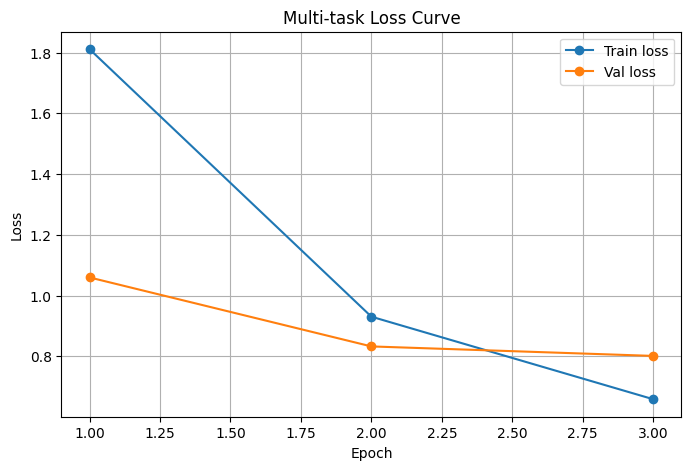

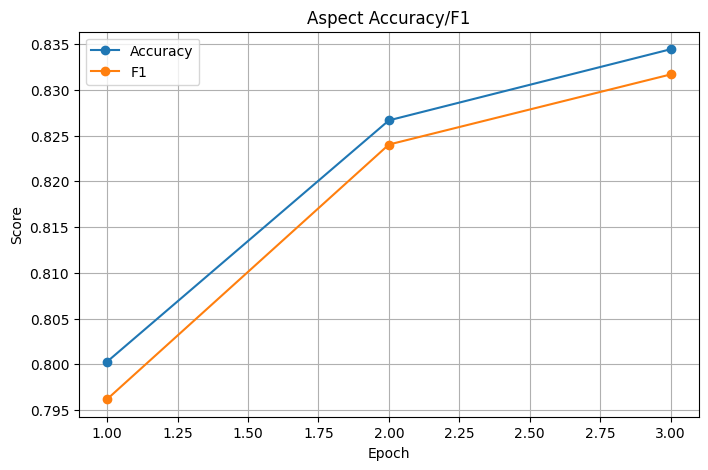

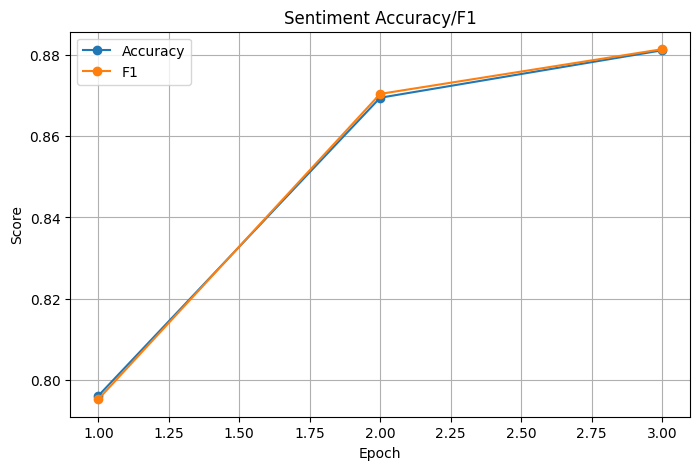

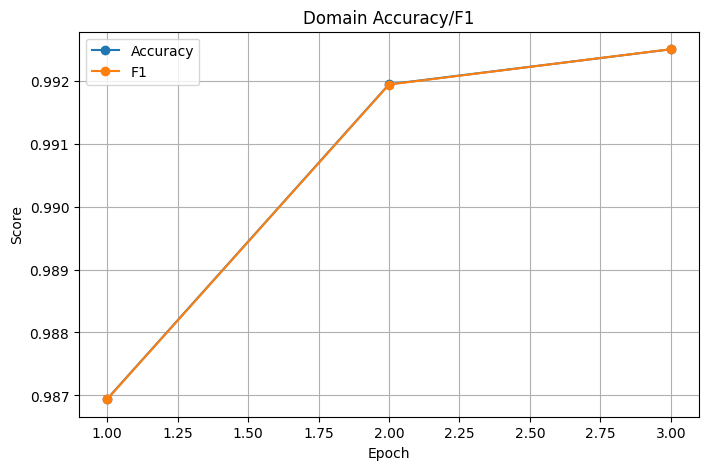

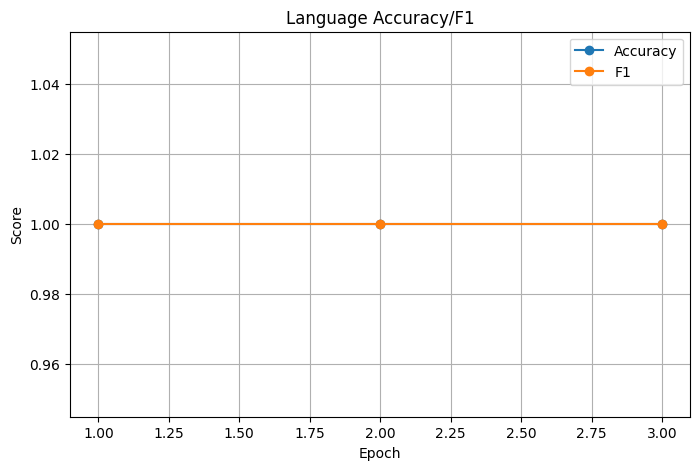

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Multi-task Loss Curve")
plt.legend(); plt.grid(True); plt.show()

for task in ["aspect", "sentiment", "domain", "language"]:
    plt.figure(figsize=(8,5))
    plt.plot(history_df["epoch"], history_df[f"{task}_acc"], marker="o", label="Accuracy")
    plt.plot(history_df["epoch"], history_df[f"{task}_f1"], marker="o", label="F1")
    plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title(f"{task.capitalize()} Accuracy/F1")
    plt.legend(); plt.grid(True); plt.show()

  0%|          | 0/450 [00:00<?, ?it/s]

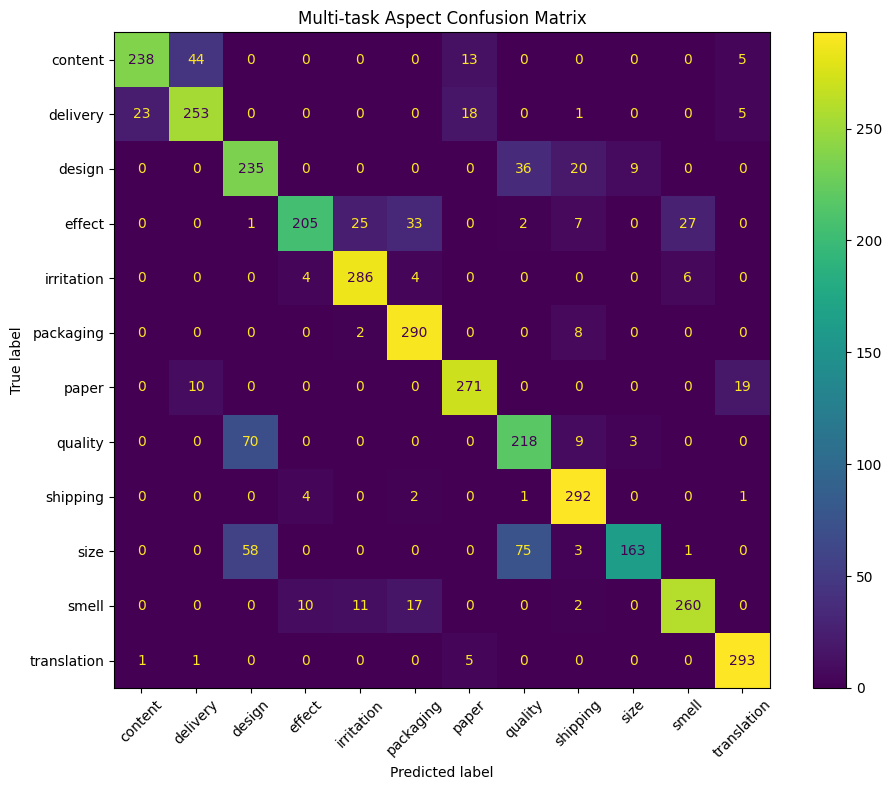

Classification report - aspect
              precision    recall  f1-score   support

     content       0.91      0.79      0.85       300
    delivery       0.82      0.84      0.83       300
      design       0.65      0.78      0.71       300
      effect       0.92      0.68      0.78       300
  irritation       0.88      0.95      0.92       300
   packaging       0.84      0.97      0.90       300
       paper       0.88      0.90      0.89       300
     quality       0.66      0.73      0.69       300
    shipping       0.85      0.97      0.91       300
        size       0.93      0.54      0.69       300
       smell       0.88      0.87      0.88       300
 translation       0.91      0.98      0.94       300

    accuracy                           0.83      3600
   macro avg       0.84      0.83      0.83      3600
weighted avg       0.84      0.83      0.83      3600



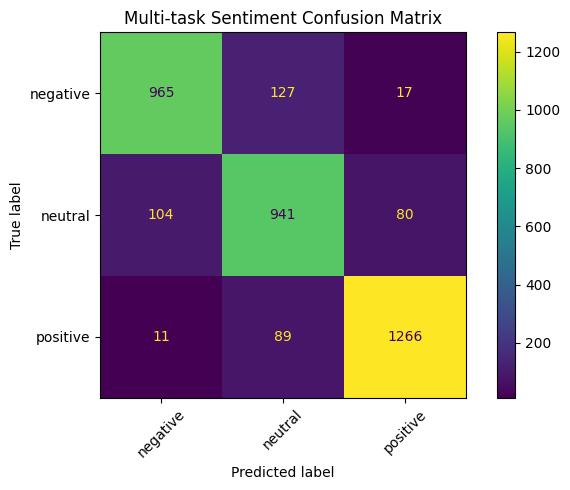

Classification report - sentiment
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      1109
     neutral       0.81      0.84      0.82      1125
    positive       0.93      0.93      0.93      1366

    accuracy                           0.88      3600
   macro avg       0.88      0.88      0.88      3600
weighted avg       0.88      0.88      0.88      3600



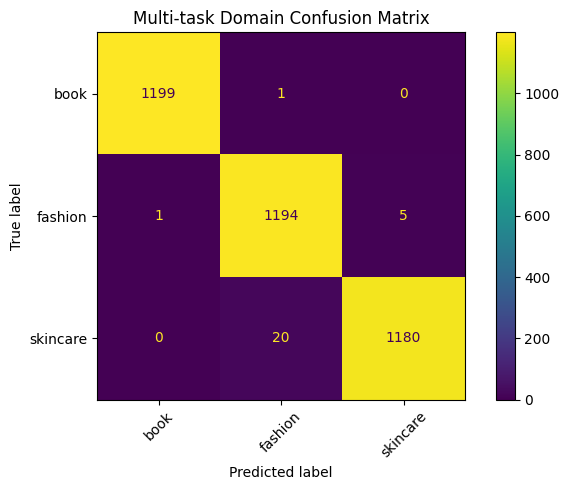

Classification report - domain
              precision    recall  f1-score   support

        book       1.00      1.00      1.00      1200
     fashion       0.98      0.99      0.99      1200
    skincare       1.00      0.98      0.99      1200

    accuracy                           0.99      3600
   macro avg       0.99      0.99      0.99      3600
weighted avg       0.99      0.99      0.99      3600



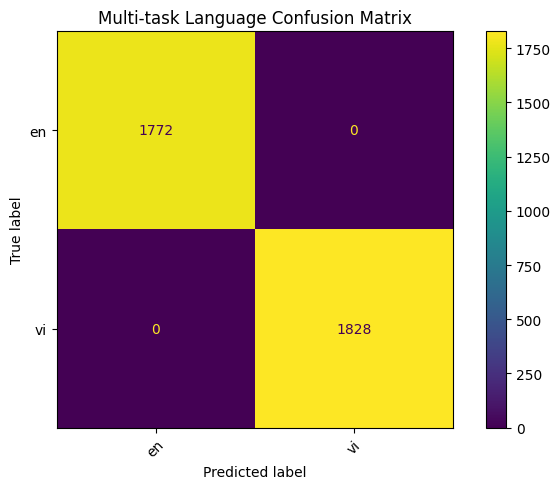

Classification report - language
              precision    recall  f1-score   support

          en       1.00      1.00      1.00      1772
          vi       1.00      1.00      1.00      1828

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600



In [13]:
_, mt_true, mt_pred = evaluate_multitask(mt_model, val_loader)
encoders = {
    "aspect": mt_aspect_encoder,
    "sentiment": mt_sentiment_encoder,
    "domain": mt_domain_encoder,
    "language": mt_language_encoder
}

for task, encoder in encoders.items():
    cm = confusion_matrix(mt_true[task], mt_pred[task])
    fig, ax = plt.subplots(figsize=(10,8) if task=="aspect" else (7,5))
    disp = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title(f"Multi-task {task.capitalize()} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    print(f"Classification report - {task}")
    print(classification_report(mt_true[task], mt_pred[task], target_names=encoder.classes_))

In [14]:
def multitask_predict(text, top_k=3):
    mt_model.eval()
    enc = tokenizer(text, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        outputs = mt_model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])

    aspect_probs = F.softmax(outputs["aspect_logits"], dim=1)[0]
    top_scores, top_ids = torch.topk(aspect_probs, top_k)
    aspects = []
    for score, idx in zip(top_scores, top_ids):
        aspects.append({
            "aspect": mt_aspect_encoder.inverse_transform([idx.item()])[0],
            "confidence": round(score.item(), 4)
        })

    sentiment_id = torch.argmax(outputs["sentiment_logits"], dim=1).item()
    domain_id = torch.argmax(outputs["domain_logits"], dim=1).item()
    language_id = torch.argmax(outputs["language_logits"], dim=1).item()

    return {
        "top_aspects": aspects,
        "sentiment": mt_sentiment_encoder.inverse_transform([sentiment_id])[0],
        "domain": mt_domain_encoder.inverse_transform([domain_id])[0],
        "language": mt_language_encoder.inverse_transform([language_id])[0]
    }

test_reviews = [
    "Áo đẹp nhưng hơi chật",
    "Kem dưỡng ẩm tốt nhưng có mùi khó chịu",
    "Nội dung sách hay nhưng giấy xấu",
    "This shirt looks great but size is too small",
    "Packaging is beautiful and delivery is fast",
    "Sản phẩm gây kích ứng da"
]

for text in test_reviews:
    print("="*70)
    print(text)
    print(multitask_predict(text, top_k=3))

Áo đẹp nhưng hơi chật
{'top_aspects': [{'aspect': 'design', 'confidence': 0.9191}, {'aspect': 'size', 'confidence': 0.0656}, {'aspect': 'quality', 'confidence': 0.0088}], 'sentiment': 'positive', 'domain': 'fashion', 'language': 'vi'}
Kem dưỡng ẩm tốt nhưng có mùi khó chịu
{'top_aspects': [{'aspect': 'smell', 'confidence': 0.7669}, {'aspect': 'effect', 'confidence': 0.2182}, {'aspect': 'irritation', 'confidence': 0.0065}], 'sentiment': 'neutral', 'domain': 'skincare', 'language': 'vi'}
Nội dung sách hay nhưng giấy xấu
{'top_aspects': [{'aspect': 'paper', 'confidence': 0.9838}, {'aspect': 'content', 'confidence': 0.0097}, {'aspect': 'translation', 'confidence': 0.0016}], 'sentiment': 'neutral', 'domain': 'book', 'language': 'vi'}
This shirt looks great but size is too small
{'top_aspects': [{'aspect': 'size', 'confidence': 0.9959}, {'aspect': 'quality', 'confidence': 0.0017}, {'aspect': 'design', 'confidence': 0.0016}], 'sentiment': 'neutral', 'domain': 'fashion', 'language': 'en'}
Pack

In [15]:
# Giải phóng model multi-task nếu GPU thiếu RAM cho BIO
# Nếu muốn giữ mt_model để test tiếp thì bỏ qua cell này.
# try:
#     mt_model_cpu = mt_model.to("cpu")
# except Exception:
#     pass

# gc.collect()
# torch.cuda.empty_cache()

aspect_keywords = {}
for domain_dict in aspect_dicts.values():
    for asp, kws in domain_dict.items():
        aspect_keywords.setdefault(asp, [])
        aspect_keywords[asp].extend(kws)

aspect_keywords = {k: sorted(list(set(v)), key=lambda x: len(x.split()), reverse=True) for k, v in aspect_keywords.items()}

bio_labels = ["O"]
for aspect in sorted(aspect_keywords.keys()):
    bio_labels.append(f"B-{aspect}")
    bio_labels.append(f"I-{aspect}")

label2id = {label: i for i, label in enumerate(bio_labels)}
id2label = {i: label for label, i in label2id.items()}
print(label2id)

{'O': 0, 'B-content': 1, 'I-content': 2, 'B-delivery': 3, 'I-delivery': 4, 'B-design': 5, 'I-design': 6, 'B-effect': 7, 'I-effect': 8, 'B-irritation': 9, 'I-irritation': 10, 'B-packaging': 11, 'I-packaging': 12, 'B-paper': 13, 'I-paper': 14, 'B-quality': 15, 'I-quality': 16, 'B-shipping': 17, 'I-shipping': 18, 'B-size': 19, 'I-size': 20, 'B-smell': 21, 'I-smell': 22, 'B-translation': 23, 'I-translation': 24}


In [16]:
def word_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", str(text), re.UNICODE)

def norm_token(t):
    return t.lower().strip()

def create_bio_tags(text):
    tokens = word_tokenize(text)
    tags = ["O"] * len(tokens)
    norm_tokens = [norm_token(t) for t in tokens]

    for aspect, keywords in aspect_keywords.items():
        for kw in keywords:
            kw_tokens = [norm_token(t) for t in word_tokenize(kw)]
            n = len(kw_tokens)
            if n == 0: continue
            for i in range(len(norm_tokens) - n + 1):
                if norm_tokens[i:i+n] == kw_tokens:
                    tags[i] = f"B-{aspect}"
                    for j in range(1, n):
                        tags[i+j] = f"I-{aspect}"
    return tokens, tags

bio_rows = []
for _, row in final_df.iterrows():
    tokens, tags = create_bio_tags(row["review"])
    if any(t != "O" for t in tags):
        bio_rows.append({
            "review": row["review"],
            "tokens": tokens,
            "bio_tags": tags,
            "domain": row["domain"],
            "language": row["language"],
            "sentiment": row["sentiment"]
        })

bio_df = pd.DataFrame(bio_rows)
print("bio_df:", bio_df.shape)

# giảm mẫu để tránh OOM Kaggle GPU
MAX_BIO_SAMPLES = 10000
if len(bio_df) > MAX_BIO_SAMPLES:
    bio_df_small = bio_df.sample(MAX_BIO_SAMPLES, random_state=SEED).reset_index(drop=True)
else:
    bio_df_small = bio_df.copy()
print("bio_df_small:", bio_df_small.shape)

bio_df: (18225, 6)
bio_df_small: (10000, 6)


In [17]:
class BIODataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_length=96):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        tokens = self.df.loc[idx, "tokens"]
        tags = self.df.loc[idx, "bio_tags"]
        enc = self.tokenizer(
            tokens, is_split_into_words=True,
            truncation=True, padding="max_length", max_length=self.max_length,
            return_tensors="pt"
        )
        word_ids = enc.word_ids(batch_index=0)
        labels = []
        prev = None
        for wid in word_ids:
            if wid is None:
                labels.append(-100)
            elif wid != prev:
                labels.append(self.label2id[tags[wid]])
            else:
                tag = tags[wid]
                if tag.startswith("B-"):
                    tag = tag.replace("B-", "I-")
                labels.append(self.label2id[tag])
            prev = wid
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(labels, dtype=torch.long)
        }

bio_train_df, bio_val_df = train_test_split(bio_df_small, test_size=0.2, random_state=SEED)
bio_train_df = bio_train_df.reset_index(drop=True)
bio_val_df = bio_val_df.reset_index(drop=True)

bio_train_dataset = BIODataset(bio_train_df, tokenizer, label2id, max_length=96)
bio_val_dataset = BIODataset(bio_val_df, tokenizer, label2id, max_length=96)

In [18]:
seqeval = evaluate.load("seqeval")

def compute_bio_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_preds, true_labels = [], []
    for pred_seq, label_seq in zip(preds, labels):
        p_tags, l_tags = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                p_tags.append(id2label[p])
                l_tags.append(id2label[l])
        true_preds.append(p_tags)
        true_labels.append(l_tags)
    res = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": res["overall_precision"],
        "recall": res["overall_recall"],
        "f1": res["overall_f1"],
        "accuracy": res["overall_accuracy"]
    }

gc.collect(); torch.cuda.empty_cache()

bio_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)
bio_model.gradient_checkpointing_enable()

bio_training_args = TrainingArguments(
    output_dir="./xlm_roberta_bio_absa",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

bio_trainer = Trainer(
    model=bio_model,
    args=bio_training_args,
    train_dataset=bio_train_dataset,
    eval_dataset=bio_val_dataset,
    compute_metrics=compute_bio_metrics
)

bio_trainer.train()
bio_trainer.evaluate()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.022788,0.012360,0.967980,0.986941,0.977368,0.999041
2,0.009515,0.004802,0.996736,0.997062,0.996899,0.999782
3,0.004283,0.003695,0.997391,0.998368,0.997879,0.999823


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 0.003694515209645033,
 'eval_precision': 0.9973907371167645,
 'eval_recall': 0.9983676134508651,
 'eval_f1': 0.9978789362049274,
 'eval_accuracy': 0.9998227493191962,
 'eval_runtime': 36.929,
 'eval_samples_per_second': 54.158,
 'eval_steps_per_second': 6.77,
 'epoch': 3.0}

In [19]:
def predict_bio(text):
    tokens = word_tokenize(text)
    enc = tokenizer(
        tokens, is_split_into_words=True,
        truncation=True, padding="max_length", max_length=96,
        return_tensors="pt"
    )
    word_ids = enc.word_ids(batch_index=0)
    enc_gpu = {k: v.to(device) for k, v in enc.items()}
    bio_model.to(device)
    bio_model.eval()
    with torch.no_grad():
        outputs = bio_model(**enc_gpu)
    pred_ids = torch.argmax(outputs.logits, dim=-1)[0].cpu().numpy()
    results = []
    prev = None
    for pred_id, wid in zip(pred_ids, word_ids):
        if wid is None: continue
        if wid != prev:
            results.append({"token": tokens[wid], "tag": id2label[pred_id]})
        prev = wid
    return results

test_texts = [
    "Áo đẹp nhưng hơi chật",
    "Kem dưỡng ẩm tốt nhưng có mùi khó chịu",
    "Nội dung sách hay nhưng giấy xấu",
    "This shirt looks great but size is too small",
    "Packaging is beautiful and delivery is fast"
]

for text in test_texts:
    print("="*70)
    print(text)
    for item in predict_bio(text):
        print(item)

Áo đẹp nhưng hơi chật
{'token': 'Áo', 'tag': 'O'}
{'token': 'đẹp', 'tag': 'B-design'}
{'token': 'nhưng', 'tag': 'O'}
{'token': 'hơi', 'tag': 'O'}
{'token': 'chật', 'tag': 'B-size'}
Kem dưỡng ẩm tốt nhưng có mùi khó chịu
{'token': 'Kem', 'tag': 'O'}
{'token': 'dưỡng', 'tag': 'B-effect'}
{'token': 'ẩm', 'tag': 'B-effect'}
{'token': 'tốt', 'tag': 'O'}
{'token': 'nhưng', 'tag': 'O'}
{'token': 'có', 'tag': 'O'}
{'token': 'mùi', 'tag': 'B-smell'}
{'token': 'khó', 'tag': 'O'}
{'token': 'chịu', 'tag': 'O'}
Nội dung sách hay nhưng giấy xấu
{'token': 'Nội', 'tag': 'B-content'}
{'token': 'dung', 'tag': 'I-content'}
{'token': 'sách', 'tag': 'O'}
{'token': 'hay', 'tag': 'O'}
{'token': 'nhưng', 'tag': 'O'}
{'token': 'giấy', 'tag': 'B-paper'}
{'token': 'xấu', 'tag': 'B-design'}
This shirt looks great but size is too small
{'token': 'This', 'tag': 'O'}
{'token': 'shirt', 'tag': 'O'}
{'token': 'looks', 'tag': 'O'}
{'token': 'great', 'tag': 'O'}
{'token': 'but', 'tag': 'O'}
{'token': 'size', 'tag': 'B-s

In [20]:
# Lưu BIO model
bio_trainer.save_model("xlm_roberta_bio_absa_model")
tokenizer.save_pretrained("xlm_roberta_bio_absa_model")

# Lưu multi-task model state_dict nếu còn biến mt_model hoặc mt_model_cpu
try:
    torch.save(mt_model.state_dict(), "multitask_xlm_roberta_state_dict.pt")
except Exception:
    try:
        torch.save(mt_model_cpu.state_dict(), "multitask_xlm_roberta_state_dict.pt")
    except Exception as e:
        print("Không lưu được mt_model:", e)

print("Done")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done


In [21]:
# Aspect-level sentiment lexicon
# Chạy cell này sau khi đã train BIO model và đã có hàm predict_bio(text)

positive_words = [
    # Vietnamese
    "đẹp", "tốt", "hay", "xinh", "ổn", "thích", "mịn", "ẩm",
    "nhanh", "vừa", "hợp", "ok", "oke", "thoải mái", "dễ chịu",
    "chắc chắn", "đáng tiền", "hài lòng", "ưng", "mượt",

    # English
    "beautiful", "good", "great", "nice", "smooth", "fast",
    "perfect", "comfortable", "excellent", "love", "liked", "fit"
]

negative_words = [
    # Vietnamese
    "chật", "xấu", "tệ", "khó chịu", "kích ứng", "mụn", "hôi",
    "chậm", "rộng", "lỏng", "bí", "nhỏ", "to", "không tốt",
    "không đẹp", "không hay", "không thích", "không ổn", "thất vọng",
    "rách", "mỏng", "cứng", "kém", "sai", "lỗi",

    # English
    "small", "tight", "bad", "ugly", "irritation", "breakout",
    "slow", "uncomfortable", "loose", "poor", "disappointed", "wrong"
]

contrast_words = [
    "nhưng", "tuy nhiên", "nhưng mà", "but", "however", "although"
]

punctuation_split = [",", ".", ";", "!", "?"]


def _lower_tokens(tokens):
    return [str(t).lower().strip() for t in tokens]


def get_clause_bounds(tokens, idx):
    """
    Lấy phạm vi mệnh đề quanh aspect term.
    Mục tiêu: tránh lấy sentiment bên trái 'nhưng' gán nhầm cho bên phải.
    Ví dụ: Áo đẹp nhưng hơi chật
    - đẹp nằm ở mệnh đề trái -> positive
    - chật nằm ở mệnh đề phải -> negative
    """
    low = _lower_tokens(tokens)

    left = idx
    while left > 0:
        prev_tok = low[left - 1]
        if prev_tok in contrast_words or tokens[left - 1] in punctuation_split:
            break
        left -= 1

    right = idx
    while right < len(tokens) - 1:
        next_tok = low[right + 1]
        if next_tok in contrast_words or tokens[right + 1] in punctuation_split:
            break
        right += 1

    return left, right


def get_aspect_sentiment(tokens, idx, window=4):
    """
    Gán sentiment cho aspect term tại vị trí idx.
    Ưu tiên:
    1. Chính token aspect là từ tích cực/tiêu cực.
    2. Các từ sentiment trong cùng mệnh đề.
    3. Cửa sổ local quanh aspect.
    """
    low = _lower_tokens(tokens)
    token = low[idx]

    # 1. Check chính token trước
    if token in negative_words:
        return "negative"
    if token in positive_words:
        return "positive"

    # 2. Check trong cùng mệnh đề
    left, right = get_clause_bounds(tokens, idx)
    clause = " ".join(low[left:right + 1])

    # Negative ưu tiên trước vì các câu kiểu "tốt nhưng mùi khó chịu"
    for word in negative_words:
        if word in clause:
            return "negative"

    for word in positive_words:
        if word in clause:
            return "positive"

    # 3. Check cửa sổ local quanh aspect
    start = max(0, idx - window)
    end = min(len(tokens), idx + window + 1)
    context = " ".join(low[start:end])

    for word in negative_words:
        if word in context:
            return "negative"

    for word in positive_words:
        if word in context:
            return "positive"

    return "neutral"

In [22]:
def merge_bio_terms(bio_result):
    """
    Gom các token BIO thành aspect term.
    Xử lý cả trường hợp model dự đoán liên tiếp B-effect B-effect
    như 'dưỡng' và 'ẩm' thay vì B-effect I-effect.
    """
    terms = []
    i = 0

    while i < len(bio_result):
        tag = bio_result[i]["tag"]

        if not tag.startswith("B-"):
            i += 1
            continue

        aspect = tag.replace("B-", "")
        start_idx = i
        term_tokens = [bio_result[i]["token"]]

        j = i + 1
        while j < len(bio_result):
            next_tag = bio_result[j]["tag"]

            # Chuẩn BIO: I-cùng-aspect
            if next_tag == f"I-{aspect}":
                term_tokens.append(bio_result[j]["token"])
                j += 1
                continue

            # Tolerant BIO: B-cùng-aspect liền kề vẫn gom chung
            if next_tag == f"B-{aspect}" and j == i + len(term_tokens):
                term_tokens.append(bio_result[j]["token"])
                j += 1
                continue

            break

        terms.append({
            "term": " ".join(term_tokens),
            "start_idx": start_idx,
            "aspect": aspect,
            "bio_tag": f"B-{aspect}"
        })

        i = j

    return terms


def predict_aspect_level_sentiment(text):
    """
    Output cuối cùng:
    term -> BIO tag -> aspect -> sentiment
    """
    bio_result = predict_bio(text)
    tokens = [item["token"] for item in bio_result]
    terms = merge_bio_terms(bio_result)

    results = []
    for term in terms:
        sentiment = get_aspect_sentiment(
            tokens=tokens,
            idx=term["start_idx"]
        )

        results.append({
            "term": term["term"],
            "bio_tag": term["bio_tag"],
            "aspect": term["aspect"],
            "sentiment": sentiment
        })

    return results


def print_aspect_level_sentiment(text):
    print("=" * 70)
    print("TEXT:")
    print(text)
    print("\nASPECT-LEVEL SENTIMENT:")

    results = predict_aspect_level_sentiment(text)

    if len(results) == 0:
        print("Không phát hiện aspect term.")
    else:
        for r in results:
            print(f"{r['term']} -> {r['bio_tag']} -> {r['aspect']} -> {r['sentiment']}")

    return results

In [23]:
# Test các câu có nhiều khía cạnh và sentiment đối nghịch nhau

test_texts = [
    "Áo đẹp nhưng hơi chật",
    "Kem dưỡng ẩm tốt nhưng có mùi khó chịu",
    "Nội dung sách hay nhưng giấy xấu",
    "This shirt looks great but size is too small",
    "Packaging is beautiful but delivery is slow",
    "Sản phẩm gây kích ứng da nhưng dưỡng ẩm tốt"
]

for text in test_texts:
    print_aspect_level_sentiment(text)

TEXT:
Áo đẹp nhưng hơi chật

ASPECT-LEVEL SENTIMENT:
đẹp -> B-design -> design -> positive
chật -> B-size -> size -> negative
TEXT:
Kem dưỡng ẩm tốt nhưng có mùi khó chịu

ASPECT-LEVEL SENTIMENT:
dưỡng ẩm -> B-effect -> effect -> positive
mùi -> B-smell -> smell -> negative
TEXT:
Nội dung sách hay nhưng giấy xấu

ASPECT-LEVEL SENTIMENT:
Nội dung -> B-content -> content -> positive
giấy -> B-paper -> paper -> negative
xấu -> B-design -> design -> negative
TEXT:
This shirt looks great but size is too small

ASPECT-LEVEL SENTIMENT:
size -> B-size -> size -> negative
small -> B-size -> size -> negative
TEXT:
Packaging is beautiful but delivery is slow

ASPECT-LEVEL SENTIMENT:
Packaging -> B-packaging -> packaging -> positive
beautiful -> B-design -> design -> positive
delivery -> B-delivery -> delivery -> negative
TEXT:
Sản phẩm gây kích ứng da nhưng dưỡng ẩm tốt

ASPECT-LEVEL SENTIMENT:
kích ứng -> B-irritation -> irritation -> negative
dưỡng ẩm -> B-effect -> effect -> positive


In [24]:
import os
import torch
import pickle

os.makedirs("saved_models", exist_ok=True)

# save tokenizer
tokenizer.save_pretrained("saved_models/tokenizer")

# save multitask model
torch.save(mt_model.state_dict(), "saved_models/multitask_model.pt")

# save BIO model
bio_model.save_pretrained("saved_models/bio_model")

# save encoders
with open("saved_models/encoders.pkl", "wb") as f:
    pickle.dump({
        "mt_aspect_encoder": mt_aspect_encoder,
        "mt_sentiment_encoder": mt_sentiment_encoder,
        "mt_domain_encoder": mt_domain_encoder,
        "mt_language_encoder": mt_language_encoder,
        "label2id": label2id,
        "id2label": id2label
    }, f)

print("Saved all models")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved all models


In [25]:
from transformers import AutoTokenizer
import os
import torch
import pickle
import shutil

# =========================
# LOAD TOKENIZER AGAIN
# =========================
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# =========================
# CREATE SAVE FOLDER
# =========================
os.makedirs("/kaggle/working/saved_models", exist_ok=True)

# =========================
# SAVE TOKENIZER
# =========================
tokenizer.save_pretrained(
    "/kaggle/working/saved_models/tokenizer"
)

# =========================
# SAVE MULTITASK MODEL
# =========================
torch.save(
    mt_model.state_dict(),
    "/kaggle/working/saved_models/multitask_model.pt"
)

# =========================
# SAVE BIO MODEL
# =========================
bio_model.save_pretrained(
    "/kaggle/working/saved_models/bio_model"
)

# =========================
# SAVE ENCODERS
# =========================
with open("/kaggle/working/saved_models/encoders.pkl", "wb") as f:
    pickle.dump({
        "mt_aspect_encoder": mt_aspect_encoder,
        "mt_sentiment_encoder": mt_sentiment_encoder,
        "mt_domain_encoder": mt_domain_encoder,
        "mt_language_encoder": mt_language_encoder,
        "label2id": label2id,
        "id2label": id2label
    }, f)

print("MODELS SAVED")

# =========================
# ZIP EVERYTHING
# =========================
shutil.make_archive(
    "/kaggle/working/saved_models",
    "zip",
    "/kaggle/working/saved_models"
)

print("ZIP CREATED")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MODELS SAVED
ZIP CREATED


In [35]:
import shutil

shutil.copy(
    "/kaggle/working/saved_models.zip",
    "/kaggle/working/outputsaved_models.zip"
)

print("DONE")

DONE


In [36]:

test_texts = [
    "Áo đẹp nhưng hơi chật",
  
]

for text in test_texts:
    print_aspect_level_sentiment(text)

TEXT:
Áo đẹp nhưng hơi chật

ASPECT-LEVEL SENTIMENT:
đẹp -> B-design -> design -> positive
chật -> B-size -> size -> negative
